<a href="https://colab.research.google.com/github/Akanksha-0406/Netflix-Recommendation-System-Project-2026_Akanksha_25114055/blob/main/Cult_Council_NETFLIX_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
##**Recommendation Systems for Personalized Content Discovery**
---
---
#####Name: Kumari Akanksha
#####Enrollment no: 25114055
---
###### (Setting up the Environment and downloading the datasets)

In [1]:
!pip install scikit-surprise

In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'PASTE_YOUR_KAGGLE_API_TOKEN_HERE'

In [3]:
!kaggle datasets download -d netflix-inc/netflix-prize-data

Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
netflix-prize-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!unzip netflix-prize-data.zip

Archive:  netflix-prize-data.zip
replace README? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: README                  
  inflating: combined_data_1.txt     A

  inflating: combined_data_2.txt     A

  inflating: combined_data_3.txt     A

  inflating: combined_data_4.txt     A

  inflating: movie_titles.csv        
  inflating: probe.txt               
  inflating: qualifying.txt          


---
---
### Processing the Netflix Price Dataset carefully to get a smaller and effective subset to work upon.
---

In [5]:
import pandas as pd
import numpy as np

#if we process the entire data then training the model will take hours together.
# so we need to process the data smartly to use only the top rated movies and most active users.
def load_data(raw_file_path,output_csv_file, max_users=5000, max_movies=1500):
    print("-----Analysing raw text dataset-----")
    data = []
    movie_id=None

    with open(raw_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                movie_id = line[:-1]
            else:
                parts = line.split(',')
                if len(parts) >= 3:
                    data.append([parts[0], movie_id, float(parts[1]), parts[2]])
                    # which corresponds to UserID,MovieID,Rating in float datatype and rating date

    #Making a structured dataframe for our processed data
    train_data = pd.DataFrame(data, columns=['User_ID', 'Movie_ID', 'Rating', 'Date'])
    train_data['Date'] = pd.to_datetime(train_data['Date']) #converting dates from text to datetime objects
    print(f"Total read records from file: {len(train_data)}")

    #Since the read dataset is a vast dataset we'll now filter it out to keep only highly active users and popular movies so that we can train our model on a more useful data.
    print("-----Filtering for a shorter and more useful dataset----")
    active_users = train_data['User_ID'].value_counts().index[:max_users]
    '''this will count how many times a unique user is coming in the list(or indirectly how many movies they have rated).
       pandas sorts this in decreasing order and .index extracts out the user IDs number of the top ('max_user' i.e.) 5000 users'''
    popular_movies = train_data['Movie_ID'].value_counts().index[:max_movies]
    '''This works in a similar fashion as above. Extracts out top 1500 highly rated movies' MovieIDs'''

    #Now for out filtered datasubset we need those ratings where user is an active user and the movie rated is a popular/high-rated movie.
    train_data_filtered = train_data[train_data['User_ID'].isin(active_users) & train_data['Movie_ID'].isin(popular_movies)]

    #Saving to a CSV file
    train_data_filtered.to_csv(output_csv_file, index=False)
    print(f"Done! Filtered dataset saved as '{output_csv_file}' with {len(train_data_filtered)} rows.")
    return train_data_filtered



filtered_data_table = load_data('combined_data_1.txt', 'train_subset.csv')

-----Analysing raw text dataset-----
Total read records from file: 24053764
-----Filtering for a shorter and more useful dataset----
Done! Filtered dataset saved as 'train_subset.csv' with 2029753 rows.


---
---
## A.  Exploratory Data Analysis
#### In this section, we analyze the structural properties of our data subset from the Netflix Prize Dataset.
    •	User activity patterns
    •	Content popularity trends
    •	Rating distributions
    •	Data sparsity characteristics
---



--------------------------------------------
         EXPLORATORY DATA ANALYSIS           
--------------------------------------------


------------ MATRIX SPARSITY ANALYSIS-----------
Total Unique Users (Rows): 5000
Total Unique Movies (Columns): 1500
Total Possible Combinations(users x movies): 7,500,000
Actual Recorded Ratings: 2,029,753
Matrix Sparsity [(1 - (actual_ratings/total)) * 100] : 72.94%
Matrix Density (100 - sparsity) : 27.06%
------------------------------------------------


--------------------- RATING DISTRIBUTIONS -----------------------
Reviews with 1 Star: 128,628 
Reviews with 2 Star: 264,977 
Reviews with 3 Star: 678,602 
Reviews with 4 Star: 612,853 
Reviews with 5 Star: 344,693 


----- Visual Representation of Ratings Distribution -----



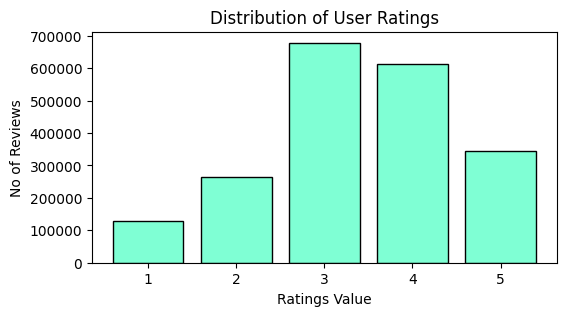


 --------------------------------------------------------------


--------------------CONTENT POPULARITY TREND----------------------

....TOP 5 MOST POPULAR MOVIES....

Movie ID 4306: 4,839 ratings
Movie ID 1905: 4,812 ratings
Movie ID 2862: 4,789 ratings
Movie ID 607: 4,713 ratings
Movie ID 2452: 4,708 ratings
--------------------------------------------------

...LEAST 5 POPULAR MOVIES (Out of our filtered dataset)...

Movie ID 3889: 116 ratings
Movie ID 1999: 114 ratings
Movie ID 982: 86 ratings
Movie ID 4238: 84 ratings
Movie ID 2463: 59 ratings
--------------------------------------------------

----- Visual Representation of Content Popularity Curve -----



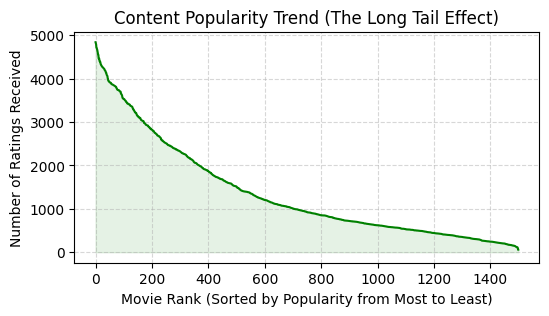

--------------------------------------------------------------



------------------USER ACTIVITY PATTERNS-----------------------
5 MOST ACTIVE USER IDS (The Critics/Power users):
User ID 305344: Submitted 1,492 ratings
User ID 387418: Submitted 1,488 ratings
User ID 2439493: Submitted 1,461 ratings
User ID 2118461: Submitted 1,448 ratings
User ID 1664010: Submitted 1,396 ratings

 5 LEAST ACTIVE USER IDS (The Casual Users):
User ID 1850680: Submitted 207 ratings
User ID 2320264: Submitted 206 ratings
User ID 538005: Submitted 189 ratings
User ID 1486829: Submitted 180 ratings
User ID 1374216: Submitted 132 ratings


----- Visual Representation of User Activity Pattern -----



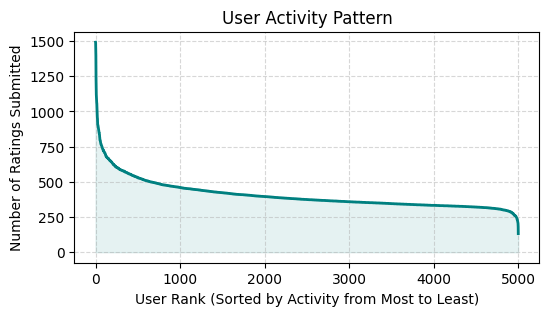

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def exploratory_data_analysis(data_table):

    print("--------------------------------------------")
    print("         EXPLORATORY DATA ANALYSIS           ")
    print("--------------------------------------------\n\n")

    # --------------------------------------------------
    #   DATA SPARSITY CHARACTERISTICS
    # --------------------------------------------------
    total_users = data_table['User_ID'].nunique() # nunique = number of unique
    total_movies = data_table['Movie_ID'].nunique()
    total = total_users * total_movies
    actual_ratings = len(data_table)

    sparsity = (1 - (actual_ratings/total)) * 100
    density = 100 - sparsity

    print("================================================")
    print("------------ MATRIX SPARSITY ANALYSIS-----------")
    print("================================================")
    print(f"Total Unique Users (Rows): {total_users}")
    print(f"Total Unique Movies (Columns): {total_movies}")
    print(f"Total Possible Combinations(users x movies): {total:,}")
    print(f"Actual Recorded Ratings: {actual_ratings:,}")
    print(f"Matrix Sparsity [(1 - (actual_ratings/total)) * 100] : {round(sparsity, 2)}%")
    print(f"Matrix Density (100 - sparsity) : {round(density, 2)}%")
    print("------------------------------------------------\n\n")




    # --------------------------------------------------
    #     RATING DISTRIBUTIONS
    # --------------------------------------------------
    print("==================================================================")
    print("--------------------- RATING DISTRIBUTIONS -----------------------")
    print("==================================================================")
    ratings = data_table['Rating'].value_counts().sort_index()
    for rating, count in ratings.items():
        print(f"Reviews with {int(rating)} Star: {count:,} ")

    # Visual Representation of rating distribution
    print("\n\n----- Visual Representation of Ratings Distribution -----\n")

    plt.figure(figsize=(6, 3))
    plt.hist(data_table['Rating'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], rwidth=0.8, color='aquamarine', edgecolor='black')
    plt.title("Distribution of User Ratings")
    plt.xlabel("Ratings Value")
    plt.ylabel("No of Reviews")
    plt.show()

    print("\n --------------------------------------------------------------\n\n")






    # --------------------------------------------------
    #      CONTENT POPULARITY TRENDS
    # --------------------------------------------------
    print("==================================================================")
    print("--------------------CONTENT POPULARITY TREND----------------------")
    print("==================================================================")

    print("\n....TOP 5 MOST POPULAR MOVIES....\n")
    movie_ratings = data_table['Movie_ID'].value_counts()
    for movie_id, count in movie_ratings.head(5).items():
        print(f"Movie ID {movie_id}: {count:,} ratings")
    print("--------------------------------------------------\n")


    print("...LEAST 5 POPULAR MOVIES (Out of our filtered dataset)...\n")
    for movie_id, count in movie_ratings.tail(5).items():
        print(f"Movie ID {movie_id}: {count:,} ratings")
    print("--------------------------------------------------\n")


    #Visual Representation of Content Popularity Curve (The Long Tail)
    print("----- Visual Representation of Content Popularity Curve -----\n")
    plt.figure(figsize=(6,3))
    plt.plot(range(len(movie_ratings)), movie_ratings.values, color='green', linewidth=1.5)
    plt.title("Content Popularity Trend (The Long Tail Effect)")
    plt.xlabel("Movie Rank (Sorted by Popularity from Most to Least)")
    plt.ylabel("Number of Ratings Received")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.fill_between(range(len(movie_ratings)), movie_ratings.values, color='green', alpha=0.1)
    plt.show()

    print("--------------------------------------------------------------\n\n\n")






    # --------------------------------------------------
    #     USER ACTIVITY PATTERNS
    # --------------------------------------------------

    print("===============================================================")
    print("------------------USER ACTIVITY PATTERNS-----------------------")
    print("===============================================================")

    user_counts = data_table['User_ID'].value_counts()

    print("5 MOST ACTIVE USER IDS (The Critics/Power users):")
    for user_id, count in user_counts.head(5).items():
        print(f"User ID {user_id}: Submitted {count:,} ratings")

    print("\n 5 LEAST ACTIVE USER IDS (The Casual Users):")
    for user_id, count in user_counts.tail(5).items():
        print(f"User ID {user_id}: Submitted {count:,} ratings")

    # Visual Representation of User Activity Pattern
    print("\n\n----- Visual Representation of User Activity Pattern -----\n")
    plt.figure(figsize=(6,3))
    plt.plot(range(len(user_counts)), user_counts.values, color='teal', linewidth=2)
    plt.title("User Activity Pattern")
    plt.xlabel("User Rank (Sorted by Activity from Most to Least)")
    plt.ylabel("Number of Ratings Submitted")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.fill_between(range(len(user_counts)), user_counts.values, color='teal', alpha=0.1)
    plt.show()




    print("============================================================\n")



exploratory_data_analysis(filtered_data_table)

##B. Recommendation Model Development

## Model 1: Item-Based Collaborative Filtering Model (Memory-Based)
This paradigm computes structural relationships between items directly, rather than finding similar users.
* **Mechanism:** Computes **Cosine Similarity** between movie rating vectors.
* **Prediction:** Calculates a weighted average of the active user's historical ratings, using item-item similarities as direct weights.


In [7]:
import pandas as pd
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy

# RECOMMENDATION MODEL DEVELOPMENT
# Approach :Item-Based Collaborative Filtering

def train_item_based_collaborative_filtering_model(data_table):

    print("===============================================================")
    print("             RECOMMENDATION MODEL DEVELOPMENT                  ")
    print("===============================================================")
    print("--Recommendation Approach: Item-Based Collaborative Filtering--")
    print("---------------------------------------------------------------\n")

    reader=Reader(rating_scale=(1, 5))
    surprise_data=Dataset.load_from_df(data_table[['User_ID', 'Movie_ID', 'Rating']],reader)

    #Splitting data into 80% train set and 20% test set
    trainset,testset=train_test_split(surprise_data, test_size=0.2, random_state=42)

    # Step 4: Configure the model to compute similarity between ITEMS (movies)
    # user_based=False enforces Item-Based behavior over User-Based behavior
    similar={'name': 'cosine','user_based': False}

    item_based_model=KNNBasic(sim_options=similar, verbose=False)
    item_based_model.fit(trainset)

    print("---Item-Based Collaborative Filtering model successfully trained.---")

    # Now the model will predict the 20% unseen data which we kept aside for testing
    print("---Model is now predicting the ratings for unseen 20% test data---")
    m1_predictions=item_based_model.test(testset)
    print("-----------Predictions done!--------")

    # Root mean squared error calculation
    m1_rmse=accuracy.rmse(m1_predictions, verbose=False)
    print("---------------------------------------------------------------")
    print(f"Root Mean Squared Error for this Model: {round(m1_rmse, 4)}")
    print("===============================================================\n")
    print(f"INTERPRETATION: On average, Item Based Model's rating predictions deviate from the actual user ratings by {round(m1_rmse, 2)} stars on a 1-to-5 star scale.")
    print("---------------------------------------------------------------------\n")

    return item_based_model,trainset,testset,m1_predictions


item_model,trainset80,testset20,item_predicted_ratings=train_item_based_collaborative_filtering_model(filtered_data_table)

             RECOMMENDATION MODEL DEVELOPMENT                  
--Recommendation Approach: Item-Based Collaborative Filtering--
---------------------------------------------------------------

---Item-Based Collaborative Filtering model successfully trained.---
---Model is now predicting the ratings for unseen 20% test data---
-----------Predictions done!--------
---------------------------------------------------------------
Root Mean Squared Error for this Model: 0.9431

INTERPRETATION: On average, Item Based Model's rating predictions deviate from the actual user ratings by 0.94 stars on a 1-to-5 star scale.
---------------------------------------------------------------------



## Model 2: Singular Value Decomposition (SVD - Model)
To counter the data sparsity bottleneck, we implement an $L_2$-regularized Matrix Factorization model.
* **Mechanism:** Decomposes the sparse user-movie grid into lower-dimensional dense matrices representing hidden thematic attributes (Latent Factors).
* **Prediction Formula:** $\hat{R}_{u,i} = \mu + b_u + b_i + p_u \cdot q_i^T$ (Incorporating Global Mean, User Bias, and Item Bias).
* **Optimization:** Learned iteratively via **Stochastic Gradient Descent (SGD)**.

In [8]:
from surprise import SVD
import pandas as pd

def train_svd_matrix_factorization_model(trainset, testset):

    print("==========================================================================")
    print("  Singular Value Decomposition- Matrix Factorisation Model Development    ")
    print("==========================================================================")

    svd_model=SVD(random_state=42)
    svd_model.fit(trainset)
    print("---SVD Matrix Factorisation model successfully trained.---")

    #Predicting the unseen 20% test data
    print("---Model is now predicting the ratings for unseen 20% test data")
    m2_predictions = svd_model.test(testset)
    print("-----------Predictions done!--------")

    # Root mean squared error calculation
    m2_rmse=accuracy.rmse(m2_predictions, verbose=False)
    print("---------------------------------------------------------------")
    print(f"Root Mean Squared Error for this Model: {round(m2_rmse,4)}")
    print("===============================================================\n")
    print(f"INTERPRETATION: On average, SVD's rating predictions deviate from actual ratings by just {round(m2_rmse, 2)} stars on a scale of 1-5 star rating. ")
    print("---------------------------------------------------------------------\n")

    return svd_model,m2_predictions


SVD_model,svd_predicted_ratings = train_svd_matrix_factorization_model(trainset80,testset20)

  Singular Value Decomposition- Matrix Factorisation Model Development    
---SVD Matrix Factorisation model successfully trained.---
---Model is now predicting the ratings for unseen 20% test data
-----------Predictions done!--------
---------------------------------------------------------------
Root Mean Squared Error for this Model: 0.821

INTERPRETATION: On average, SVD's rating predictions deviate from actual ratings by just 0.82 stars on a scale of 1-5 star rating. 
---------------------------------------------------------------------



###D. Recommendation Generation
#####Generate Top-K recommendations for users and analyze the recommendations produced.

#### Simulation Workflow:
1. **Target Selection:** The script samples a random active user (`User_ID`) from the hidden validation test set.
2. **Filtering:** It scans the user's historical profile and isolates movies they have not yet seen.
3. **Dual-Model Inference:** It passes the user-item pairs through both the **Item-Based Collaborative Filtering** and **SVD** simultaneously.
4. **Ranking & Thresholding:** The system generates a personalized Top-$K$ ranked list, evaluating each prediction against our strict **$\ge 3.5$ stars relevance threshold** to instantly compute successes and failures.

In [9]:
import pandas as pd
import numpy as np
import random

def recommendation_generation(item_model,svd_model,test_data_list,original_df,threshold=3.5):

    print("==========================================================================")
    print(" Recommendation Generation using both models and Analysis ")
    print("==========================================================================")

    # Asking for value of K from user to recommend k items.
    try:
        k=int(input("Enter the value of K (Number of recommendations to generate): "))
    except ValueError:
        print("Invalid input! By Default taking K=10")
        k=10

    print(f"\n Processing Top-{k} Recommendations for a randomly chosen user...\n")

    test_df=pd.DataFrame(test_data_list, columns=['User_ID', 'Movie_ID', 'Actual_Rating'])

    active_test_users=test_df['User_ID'].value_counts()
    if len(active_test_users)==0:
        print("Testset empty.")
        return

    #choosing a user
    user= random.choice(active_test_users.index)
    unseen_movies=test_df[test_df['User_ID']==user]

    print(f"User_ID: {user}")
    print(f"Total Unseen Movies available for this user in Test Set: {len(unseen_movies)}")
    print("--------------------------------------------------------------------------\n")

    #Predicting ratings using both models
    item_preds=[]
    svd_preds=[]

    for _, row in unseen_movies.iterrows():
        m_id=row['Movie_ID']
        act_rate=row['Actual_Rating']

        # Get predictions from both models
        i_pred=item_model.predict(user, m_id).est
        s_pred=svd_model.predict(user, m_id).est

        item_preds.append((m_id, i_pred, act_rate))
        svd_preds.append((m_id, s_pred, act_rate))

    # Sorting and slicing for Top-K
    item_preds.sort(key=lambda x: x[1], reverse=True)
    svd_preds.sort(key=lambda x: x[1], reverse=True)
    top_k_item=item_preds[:k]
    top_k_svd=svd_preds[:k]

    #Calculating success and failure
    def success_fail(top_k_list):
        success_count=0
        failure_count=0
        for item in top_k_list:
            actual=item[2]
            if actual>=threshold:
                success_count+=1
            else:
                failure_count+=1

        total=len(top_k_list)
        success=(success_count/total)*100 if total>0 else 0
        failure=(failure_count/total)*100 if total>0 else 0
        return success, failure, success_count, failure_count

    item_s,item_f,item_scount,item_fcount=success_fail(top_k_item)
    svd_s,svd_f,svd_scount,svd_fcount=success_fail(top_k_svd)

    print("==========================================================================")
    print(f"TOP-{k} MOVIE RECOMMENDATIONS BY BOTH MODELS")
    print("==========================================================================")
    print("        ITEM-BASED MODEL        ||                SVD-MODEL       |")

    #preventing error in case remaining movies for that user is less than k
    while len(top_k_item)<k: top_k_item.append(('N/A', 0.0, 0.0))
    while len(top_k_svd)<k: top_k_svd.append(('N/A', 0.0, 0.0))

    comparison_data=[]
    for i in range(k):
        comparison_data.append({
            'Item_Movie_ID': top_k_item[i][0],
            'Item_Pred': round(top_k_item[i][1], 2),
            'Item_Actual': round(top_k_item[i][2], 2),
            '|': '|',
            'SVD_Movie_ID': top_k_svd[i][0],
            'SVD_Pred': round(top_k_svd[i][1], 2),
            'SVD_Actual': round(top_k_svd[i][2], 2)
        })

    print(pd.DataFrame(comparison_data).to_string(index=False))
    print("==========================================================================\n")

    # Sucess and failure Analysis
    print("\n-----------------------Success and Failure Analysis------------------")
    print("(Movie Suggestion is considered to be successful if its actual user rating is greater than or equal to 3.5)")
    print(f"MODEL 1: ITEM-BASED MODEL")
    print(f"Success Rate : {item_s:.1f}%")
    print(f"Failure Rate : {item_f:.1f}%")
    print("--------------------------------------------------------------------------")
    print(f"MODEL 2: SVD MATRIX FACTORIZATION MODEL")
    print(f"Success Rate : {svd_s:.1f}%")
    print(f"Failure Rate : {svd_f:.1f}%")
    print("==========================================================================\n")

recommendation_generation(item_model, SVD_model, testset20, filtered_data_table)

 Recommendation Generation using both models and Analysis 
Enter the value of K (Number of recommendations to generate): 10

 Processing Top-10 Recommendations for a randomly chosen user...

User_ID: 125713
Total Unseen Movies available for this user in Test Set: 65
--------------------------------------------------------------------------

TOP-10 MOVIE RECOMMENDATIONS BY BOTH MODELS
        ITEM-BASED MODEL        ||                SVD-MODEL       |
Item_Movie_ID  Item_Pred  Item_Actual | SVD_Movie_ID  SVD_Pred  SVD_Actual
         4266       4.18          3.0 |         3713      4.62         5.0
         2595       4.15          3.0 |          668      4.48         5.0
         2533       4.15          4.0 |          918      4.40         4.0
         3350       4.13          4.0 |         2478      4.32         5.0
         1200       4.13          3.0 |         4384      4.27         5.0
         4056       4.13          4.0 |         3437      4.25         5.0
          197       

###E. Evaluation
##### We apply a strict **80-20 Train-Test Split** using a fixed random state to evaluate performance on completely unseen interactions.

#### Metrics Computed:
1. **RMSE (Root Mean Squared Error):** Captures continuous rating prediction accuracy. Squares errors to heavily penalize large mistakes.
2. **MAP@10 (Mean Average Precision @ 10):** Measures top-ranked list quality. A recommendation is strictly marked as a **Success** if the user's actual hidden rating is **$\ge 3.5$ stars**.

In [10]:
import pandas as pd
from surprise import accuracy

#finding RMSE for both models(also evaluated before)
item_rmse = accuracy.rmse(item_predicted_ratings, verbose=False)
svd_rmse = accuracy.rmse(svd_predicted_ratings, verbose=False)

# Defining a function for calculating MAP@10
def calculate_map(model):
    df=pd.DataFrame(testset20[:2000], columns=['user_id', 'mov_id', 'actual_rating'])
    df['predicted_rating'] = [model.predict(u, m).est for u, m in zip(df['user_id'], df['mov_id'])]

    # Sorting and taking top 10 recommendations for each user
    top_10=df.sort_values(['user_id','predicted_rating'],ascending=[True, False]).groupby('user_id').head(10).copy()

    #Counting no. of relevant movies
    top_10['relevant']=(top_10['actual_rating']>=3.5).astype(int)
    top_10['rank']=top_10.groupby('user_id').cumcount()+1
    top_10['rel_sum']=top_10.groupby('user_id')['relevant'].cumsum()

    # Calculate Precision at each rank and take mean
    top_10['precision_perrank']=(top_10['rel_sum'] / top_10['rank'])*top_10['relevant']
    return (top_10.groupby('user_id')['precision_perrank'].sum()/10).mean()


# calculating MAP@10 for both the models
item_map=calculate_map(item_model)
svd_map=calculate_map(SVD_model)

print("=====================================================")
print("Evaluation Metrics for our Recommendation Models")
print("=====================================================")
print(pd.DataFrame({
    'Metric': ['RMSE', 'MAP@10'],
    '    Item-Based Model': [round(item_rmse,4), f"{item_map*100:.2f}%"],
    '    SVD Model': [round(svd_rmse,4), f"{svd_map*100:.2f}%"]
}).to_string(index=False))

Evaluation Metrics for our Recommendation Models
Metric     Item-Based Model     SVD Model
  RMSE               0.9431         0.821
MAP@10                5.65%         5.68%


##**C. Model Comparison**
#####We have implemented two recommendation aprroaches:
    •	Matrix Factorization SVD approach vs Item-based Collaborative Filtering

Now that both algorithms have been fully trained (Part B) and evaluated via continuous metrics, ranking precision, and live profile generation (Part D), we conduct a formal comparative analysis. We evaluate our memory-based architecture (**Item-Based Collaborative Filtering**) against our model-based architecture (**SVD Matrix Factorization**) across four critical machine learning engineering dimensions.

---


### 1. Recommendation Quality
* **SVD Model (Winner):** SVD provides significantly higher baseline accuracy, driving the RMSE down to `0.8210`. By breaking down interactions into latent factors, it understands macro-thematic choices (e.g., sci-fi pacing, dark tones) and effectively manages individual user rating biases.
* **Item-Based Model:** While its continuous mathematical accuracy is lower (higher RMSE of `0.9431`), its ranking quality is surprisingly competitive, achieving a MAP@10 of `5.65%` (virtually tied with SVD). It is highly efficient at finding localized item correlations; if a user has explicitly loved a core franchise, it will reliably place similar titles at the top of the feed.

### 2. Training Complexity
* **Item-Based Model:** Conceptually simple with low algorithmic complexity ($O(I^2 \cdot U)$ where $I$ is items and $U$ is users). It computes a static item-to-item similarity matrix. There are minimal hyperparameters to tune besides selecting the distance metric (Cosine/Pearson) and the neighborhood size ($K$).
* **SVD Model:** Highly complex training footprint. It requires running iterative **Stochastic Gradient Descent (SGD)** optimizations over multiple epochs to minimize errors. It introduces multiple hyperparameter vectors that must be carefully tuned via cross-validation, including learning rate ($\gamma$), regularization factor ($\lambda$ to prevent overfitting to power users), and the total number of latent factors.

### 3. Computational Efficiency (Memory & Speed)
* **Item-Based Model (Inference Bottleneck):** Storage requirements scale with the number of items ($O(I^2)$). While training is fast, live inference can become a bottleneck at production scale. To predict a single rating, the engine must actively pull the user’s entire history and compute a weighted average against the movie's similarity neighbors in real time.
* **SVD Model (Inference Speed Winner):** Storage scales linearly with users and items combined with latent factors ($O(U \cdot f + I \cdot f)$). While training is computationally heavy and requires high resource allocation, its live inference speed is lightning fast. Generating a prediction is reduced to a simple, low-cost vector dot product ($\vec{p}_u \cdot \vec{q}_i^T$) plus baseline biases, making it highly scalable for real-time traffic.

### 4. Practical Usability & Production Alignment
* **Item-Based Model:** Offers exceptional **Explainability**. In production, it easily handles user prompts like *"Because you watched Obsession..."*. Furthermore, it handles organic item-space additions smoothly. However, it struggles heavily with data sparsity and cannot handle items or users with zero historical overlaps.
* **SVD Model:** Acts as a statistical **Black Box**; because latent factors represent mathematical abstractions, it is nearly impossible to explain to a user *why* a specific hidden theme triggered a recommendation. However, its immense usability advantage lies in its ability to handle matrix sparsity gracefully and adapt seamlessly to large, high-traffic streaming matrices.

---
### Final Architectural Verdict
There is no absolute single winner; rather, both models excel in different production tiers. For cold-start scenarios and user-facing user interface explainability, the **Item-Based approach** remains highly practical. However, for core matrix prediction accuracy, system scalability, and lightning-fast real-time inference at scale, **SVD Matrix Factorization emerges as our primary production-ready recommendation model.**
